In [4]:
import os as os
import sys

# adding folders to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd()  , '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

akshat_lisa_root = os.path.abspath(os.path.join(os.getcwd()  , '..',))
if akshat_lisa_root not in sys.path:
    sys.path.insert(0, akshat_lisa_root)

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from bbhx.waveformbuild import BBHWaveformFD
from bbhx.waveforms.phenomhm import PhenomHMAmpPhase
from bbhx.response.fastfdresponse import LISATDIResponse
from bbhx.likelihood import Likelihood, HeterodynedLikelihood
from bbhx.utils.constants import *
from bbhx.utils.transform import *
from scripts.lisa_mbbh_strain import lisa_mbbh_strain

from lisatools.sensitivity import get_sensitivity

np.random.seed(111222)

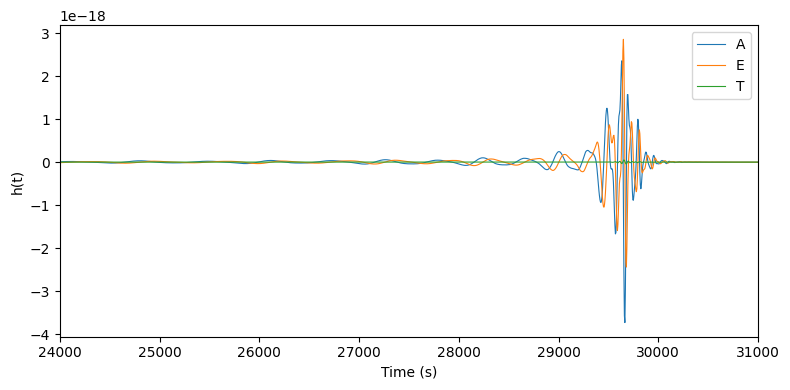

In [6]:
t, hA, hE, hT = lisa_mbbh_strain(
    m1=1e6, m2=5e5,
    a1=0.2, a2=0.4,
    dist=18e3 * PC_SI * 1e6,
    phi_ref=0.0,
    f_ref=0.0,
    inc=np.pi/3,
    lam=np.pi/5,
    beta=np.pi/4,
    psi=np.pi/6,
    t_ref=0.5 * YRSID_SI,
    N=10000,
    dt=5.0
)

plt.figure(figsize=(8,4))
plt.plot(t, hA, lw=0.8, label='A')
plt.plot(t, hE, lw=0.8, label='E')
plt.plot(t, hT, lw=0.8, label='T')
plt.xlabel('Time (s)')
plt.ylabel('h(t)')
plt.xlim(24000, 31000)
plt.legend(); plt.tight_layout(); plt.show()

Text(0, 0.5, '$\\tilde{h}(f)$ (Hz$^{-1/2}$)')

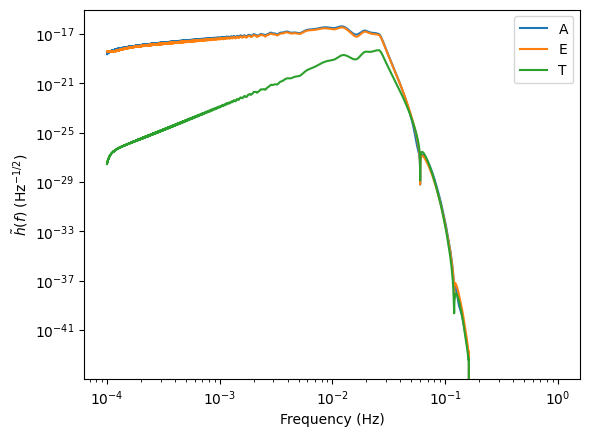

In [24]:
wave_gen = BBHWaveformFD(amp_phase_kwargs=dict(run_phenomd=False))

# set parameters
f_ref = 0.0  # let phenom codes set f_ref -> fmax = max(f^2A(f))
phi_ref = 0.0 # phase at f_ref
m1 = 1e6 
m2 = 5e5
a1 = 0.2
a2 = 0.4
dist = 18e3  * PC_SI * 1e6 # 3e3 in Mpc 
inc = np.pi/3.
beta = np.pi/4.  # ecliptic latitude
lam = np.pi/5.  # ecliptic longitude
psi = np.pi/6.  # polarization angle 
t_ref = 0.5 * YRSID_SI  # t_ref  (in the SSB reference frame)

# frequencies to interpolate to
freq_new = np.logspace(-4, 0, 10000)
modes = [(2,2), (2,1), (3,3), (3,2), (4,4), (4,3)]

wave = wave_gen(m1, m2, a1, a2,
                          dist, phi_ref, f_ref, inc, lam, 
                          beta, psi, t_ref, freqs=freq_new,
                          modes=modes, direct=False, fill=True, squeeze=True, length=1024)[0] 

for i, let in enumerate(["A", "E", "T"]):
    plt.loglog(freq_new, np.abs(wave[i]), label=let)
plt.legend()
plt.xlabel("Frequency (Hz)")
plt.ylabel(r"$\tilde{h}(f)$ (Hz$^{-1/2}$)")


0.2


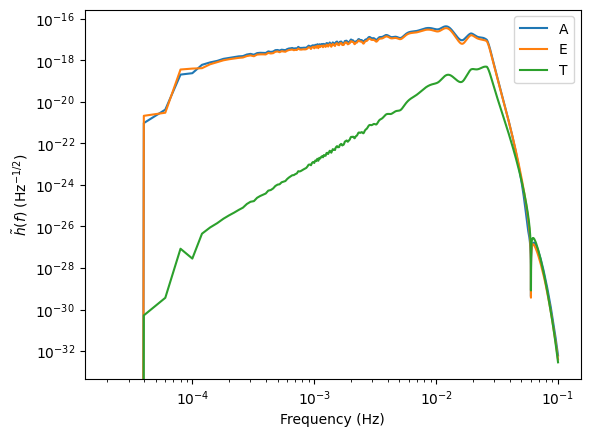

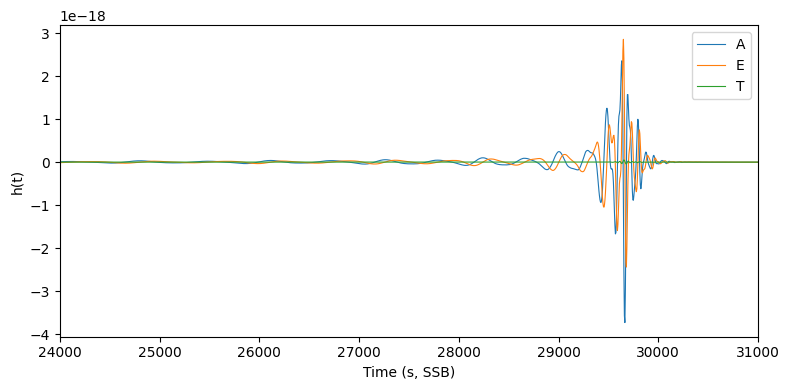

In [34]:
wave_gen = BBHWaveformFD(amp_phase_kwargs=dict(run_phenomd=False))

f_ref = 0.0  # let phenom codes set f_ref -> fmax = max(f^2A(f))
phi_ref = 0.0 # phase at f_ref
m1 = 1e6 
m2 = 5e5
a1 = 0.2
a2 = 0.4
dist = 18e3  * PC_SI * 1e6 # 3e3 in Mpc 
inc = np.pi/3.
beta = np.pi/4.  # ecliptic latitude
lam = np.pi/5.  # ecliptic longitude
psi = np.pi/6.  # polarization angle 
t_ref = 0.5 * YRSID_SI  # t_ref  (in the SSB reference frame)
N = 10000

dt = 5.0
fs = 1 / dt
t      = np.arange(N)/fs

# frequencies to interpolate to
# freq_new = np.linspace(10**(-4), 10**0, N)
freq_new = np.fft.rfftfreq(N, d=1/fs)

modes = [(2,2), (2,1), (3,3), (3,2), (4,4), (4,3)]

wave = wave_gen(m1, m2, a1, a2,
                          dist, phi_ref, f_ref, inc, lam, 
                          beta, psi, t_ref, freqs=freq_new,
                          modes=modes, direct=False, fill=True, squeeze=True, length=1024)[0] 


## Time domain: 
hA = np.fft.irfft(wave[0], n=N) 
hE = np.fft.irfft(wave[1], n=N) 
hT = np.fft.irfft(wave[2], n=N) 

for i, let in enumerate(["A", "E", "T"]):
    plt.loglog(freq_new, np.abs(wave[i]), label=let)
plt.legend()
plt.xlabel("Frequency (Hz)")
plt.ylabel(r"$\tilde{h}(f)$ (Hz$^{-1/2}$)")



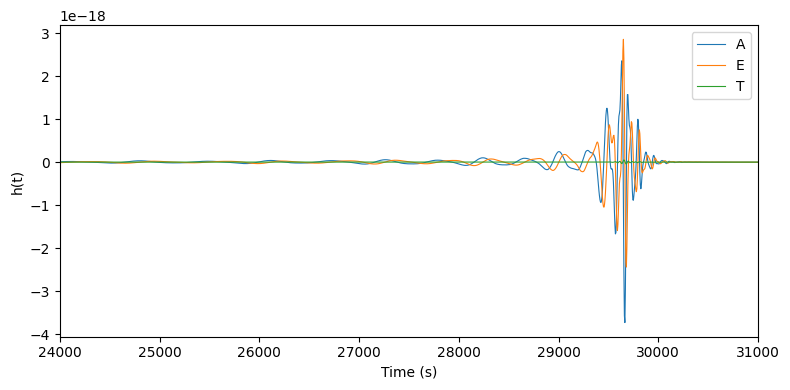

In [10]:
from lisagwresponse import GalacticBinary

In [14]:
t = np.arange(0, 1E4, 5) # sampled at 0.2 Hz
galbin = GalacticBinary(A=1E-20, f=1E-3, orbits="dist/orbit_data/orbits.h5", gw_beta=np.pi / 4, gw_lambda=0)

# response_12_21 = galbin.compute_gw_response(t, [12, 21])[0]
# response_all = galbin.compute_gw_response(t) # by default, all links

You are using an orbit file in a version that might not be fully supported
You are using an orbit file in a version that might not be fully supported


In [15]:
galbin

In [22]:
# imports 
from bbhx.waveforms.phenomhm import PhenomHMAmpPhase
from lisatools.sensitivity import get_sensitivity

In [23]:
# clear (for internal clearing of answers)
 
wave_gen = PhenomHMAmpPhase()

m1 = 2e6
m2 = 7e5
chi1 = 0.5
chi2 = 0.7
dist = 15 * 1e9 * PC_SI
phi_ref = 0.6
f_ref = 0.0
t_ref = 1e6 # seconds
length = 1024

wave_gen(m1, m2, chi1, chi2, dist, phi_ref, f_ref, t_ref, length)

Text(0, 0.5, 'Characteristic Strain')

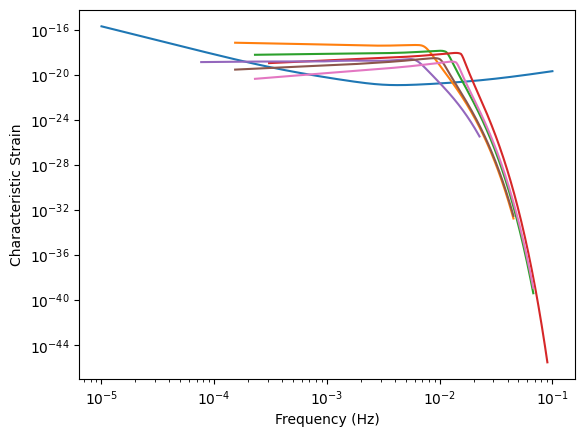

In [28]:
fn = np.logspace(-5, -1, 10000)
Sn_char_strain = get_sensitivity(fn, sens_fn="LISASens", return_type="char_strain") 


plt.loglog(fn, Sn_char_strain)
for i in range(6):
    char_strain = wave_gen.freqs_shaped[0, i] * wave_gen.amp[0, i]
    plt.loglog(wave_gen.freqs_shaped[0, i], char_strain)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Characteristic Strain")

In [29]:
print(wave_gen.amp)
print(wave_gen.amp.shape)
print(wave_gen.amp[0,1])

[[[4.54316735e-14 4.51336732e-14 4.48376100e-14 ... 5.91725996e-32
   4.82565021e-32 3.93143698e-32]
  [2.57489568e-15 2.56274871e-15 2.55065805e-15 ... 1.09925179e-38
   8.18739512e-39 6.08881797e-39]
  [3.52781894e-16 3.51768635e-16 3.50758150e-16 ... 7.33084177e-45
   4.98884809e-45 3.38814991e-45]
  [1.73799119e-15 1.72947618e-15 1.72100144e-15 ... 1.83246239e-24
   1.64925024e-24 1.48363239e-24]
  [1.87090852e-16 1.86553491e-16 1.86017600e-16 ... 1.00598462e-31
   8.22427272e-32 6.71688877e-32]
  [1.89459861e-17 1.89265947e-17 1.89072157e-17 ... 3.28425500e-38
   2.45416134e-38 1.83109035e-38]]]
(1, 6, 1024)
[2.57489568e-15 2.56274871e-15 2.55065805e-15 ... 1.09925179e-38
 8.18739512e-39 6.08881797e-39]


In [40]:
betas = np.random.uniform(0, np.pi / 2)      # scalar
lambdas = np.random.uniform(0, 2 * np.pi)    # scalar

# Then just pass directly:
source = GalacticBinary(
    amps[0],
    freqs[0],
    orbits="dist/orbit_data/orbits.h5",
    gw_beta=betas,
    gw_lambda=lambdas
)

source.write(path="gws.h5", dt=1.0, size=1)

You are using an orbit file in a version that might not be fully supported
You are using an orbit file in a version that might not be fully supported


TypeError: Response.write() got an unexpected keyword argument 'dt'

In [49]:
from lisagwresponse import GalacticBinary
import numpy as np
from h5py import Dataset, File

orbits = "dist/orbit_data/orbits.h5"
with File(orbits) as orbitf:
    t0 = orbitf.attrs["t0"]

# draw a *single* set of parameters
amp    = np.random.normal(1e-20, 1e-21)
freq   = np.random.uniform(5e-4, 2e-3)
beta   = np.random.uniform(0, np.pi/2)
lambd  = np.random.uniform(0, 2*np.pi)

src = GalacticBinary(
    amp,
    freq,
    orbits="dist/orbit_data/orbits.h5",
    gw_beta=beta,
    gw_lambda=lambd,
)
links = np.array([12, 21])
times = t0 + 10.0 + np.arange(100) * 1.0

# generate *one* time‐sample response (dt=1.0)
resp = src.compute_gw_response(
    times,
    links
)

# write that single-sample file
src.write("gws.h5")


You are using an orbit file in a version that might not be fully supported
You are using an orbit file in a version that might not be fully supported
You are using an orbit file in a version that might not be fully supported


ValueError: Found x value not in the domain

In [57]:
orbits = "dist/orbit_data/keplerian-orbits-2-0.h5"

with File(orbits) as orbitf:
    t0 = orbitf.attrs["t0"]

galbin = GalacticBinary(
    A=1e-21,
    f=2e-3,
    df=1e-9,
    gw_beta=0,
    gw_lambda=0,
    orbits=orbits,
)

links = np.array([12, 21])
times = np.arange(t0 + 100, t0 + 150, 10)
response = galbin.compute_gw_response(times, links)

links = np.array([12, 21, 31])
times = np.arange(t0 + 100, t0 + 150, 5)
response = galbin.compute_gw_response(times, links)

times = t0 + 10.0 + np.arange(100) * 1.0
response = galbin.compute_gw_response(times, links)
galbin.write(path="gws.h5")

You are using a GW file in a version that might not be fully supported


ValueError: Found x value not in the domain